# East River HRU Quicklook (Direct Plotting)

This notebook now uses direct shapefile plotting for QA.

Workflow:
1. Load config and shapefiles.
2. Plot raw HRU classes directly from hru_gdf.
3. Plot raw soil/land intersection classes directly from soil_gdf and land_gdf.
4. Show a compact HRU ordering check table (HRU_ID, elevClass, aspect).

Use after running:
`conda run -n ess-project-env python ess-project/modeling/04-distributed/run_east_river_distributed_workflow_light.py --config ess-project/0_config_files/config_East_River_distributed_elevAspect.yaml --preset minimal`

In [46]:
from pathlib import Path
import sys

import geopandas as gpd
import matplotlib.pyplot as plt
import pandas as pd
import xarray as xr
import yaml

# Point to the repo root so local imports below are stable when run from VS Code.
REPO_ROOT = Path('/home/dlhogan/projects/forked-repos/CONFLUENCE-uwmtnhydro')
if str(REPO_ROOT) not in sys.path:
    sys.path.append(str(REPO_ROOT))

# Change this to your active distributed config when needed.
CONFIG_PATH = REPO_ROOT / 'ess-project' / '0_config_files' / 'config_East_River_distributed_elevAspect.yaml'

# Optional: set to True to regenerate HRU diagnostics CSV if missing.
AUTO_EXPORT_IF_MISSING = False

# Optional: set to True to always rebuild the HRU diagnostics CSV for fresh notebook reads.
FORCE_SUMMARY_REFRESH = True

# Optional continuous elevation bins for CSV export. Leave empty string to skip.
EXPORT_ELEVATION_BANDS = ''  # example: '2500,2800,3100,3400'

plt.style.use('default')
%matplotlib inline
print(f'Using config: {CONFIG_PATH}')

Using config: /home/dlhogan/projects/forked-repos/CONFLUENCE-uwmtnhydro/ess-project/0_config_files/config_East_River_distributed_elevAspect.yaml


In [47]:
# Keep helper code short and explicit so debugging is easy.
# Import helper script directly from its file path because this folder name has hyphens.
import importlib.util
import re

export_script = REPO_ROOT / 'ess-project' / 'modeling' / '04-distributed' / 'export_hru_attributes.py'
spec = importlib.util.spec_from_file_location('export_hru_attributes', export_script)
mod = importlib.util.module_from_spec(spec)
spec.loader.exec_module(mod)
export_hru_tables = mod.export_hru_tables

def load_config(path: Path) -> dict:
    with path.open('r', encoding='utf-8') as fp:
        return yaml.safe_load(fp) or {}


def project_dir_from_config(cfg: dict) -> Path:
    return Path(cfg['CONFLUENCE_DATA_DIR']) / f"domain_{cfg['DOMAIN_NAME']}"


def resolve_hru_shapefile(cfg: dict, project_dir: Path) -> Path:
    # Use explicit CATCHMENT_SHP_NAME when provided.
    name = cfg.get('CATCHMENT_SHP_NAME', 'default')
    if name == 'default' or not name:
        method = str(cfg.get('DOMAIN_DISCRETIZATION', 'GRUs')).replace(',', '_')
        name = f"{cfg['DOMAIN_NAME']}_HRUs_{method}.shp"

    # Keep path logic transparent: default project path unless overridden.
    catchment_path = cfg.get('CATCHMENT_PATH', 'default')
    if catchment_path == 'default' or not catchment_path:
        shp_dir = project_dir / 'shapefiles' / 'catchment'
    else:
        shp_dir = Path(catchment_path)
    return shp_dir / name


def diagnostics_dir(project_dir: Path) -> Path:
    return project_dir / 'diagnostics' / 'hru_attributes'


def resolve_intersection_shapefiles(cfg: dict, project_dir: Path) -> tuple[Path, Path]:
    soil_dir = cfg.get('INTERSECT_SOIL_PATH', 'default')
    if soil_dir == 'default' or not soil_dir:
        soil_dir = project_dir / 'shapefiles' / 'catchment_intersection' / 'with_soilgrids'
    else:
        soil_dir = Path(soil_dir)

    soil_name = cfg.get('INTERSECT_SOIL_NAME', 'catchment_with_soilclass.shp')
    if soil_name == 'default' or not soil_name:
        soil_name = 'catchment_with_soilclass.shp'
    soil_shp = soil_dir / soil_name

    land_dir = cfg.get('INTERSECT_LAND_PATH', 'default')
    if land_dir == 'default' or not land_dir:
        land_dir = project_dir / 'shapefiles' / 'catchment_intersection' / 'with_landclass'
    else:
        land_dir = Path(land_dir)

    land_name = cfg.get('INTERSECT_LAND_NAME', 'catchment_with_landclass.shp')
    if land_name == 'default' or not land_name:
        land_name = 'catchment_with_landclass.shp'
    land_shp = land_dir / land_name

    return soil_shp, land_shp


def resolve_summa_table_path(cfg: dict, project_dir: Path, table_name: str) -> Path:
    settings_dir = cfg.get('SETTINGS_SUMMA_PATH', 'default')
    if settings_dir == 'default' or not settings_dir:
        settings_dir = project_dir / 'settings' / 'SUMMA'
    else:
        settings_dir = Path(settings_dir)

    candidates = [
        Path(settings_dir) / table_name,
        REPO_ROOT / 'ess-project' / '0_base_settings' / 'SUMMA' / table_name,
        REPO_ROOT / '0_base_settings' / 'SUMMA' / table_name,
    ]

    for candidate in candidates:
        if candidate.exists():
            return candidate

    raise FileNotFoundError(f'Could not find {table_name} in expected locations')


def parse_summa_class_lookup(table_path: Path, section_name: str) -> dict[int, str]:
    lines = table_path.read_text(encoding='utf-8').splitlines()
    in_section = False
    lookup: dict[int, str] = {}

    for raw_line in lines:
        line = raw_line.strip()
        if not line:
            continue

        if line == section_name:
            in_section = True
            continue

        if not in_section:
            continue

        if line.startswith('TOPT_DATA'):
            break

        # Match class records like:
        # 12, ... 'Barren Tundra'   OR   3 ... 'LOAM'
        match = re.match(r'^\s*(\d+)\s*,?\s+.*\'([^\']+)\'\s*$', raw_line)
        if not match:
            continue

        class_id = int(match.group(1))
        class_name = match.group(2).strip()
        lookup[class_id] = class_name

    return lookup


def load_rosetta_soil_lookup(cfg: dict, project_dir: Path) -> dict[int, str]:
    table = resolve_summa_table_path(cfg, project_dir, 'TBL_SOILPARM.TBL')
    return parse_summa_class_lookup(table, 'ROSETTA')


def load_modis_land_lookup(cfg: dict, project_dir: Path) -> dict[int, str]:
    table = resolve_summa_table_path(cfg, project_dir, 'TBL_VEGPARM.TBL')
    return parse_summa_class_lookup(table, 'MODIFIED_IGBP_MODIS_NOAH')


def dominant_class_from_columns(df: gpd.GeoDataFrame, prefixes: list[str]) -> tuple[pd.Series, list[str]]:
    class_cols = [
        col for col in df.columns
        if any(col.startswith(prefix) for prefix in prefixes)
    ]
    if not class_cols:
        return pd.Series(pd.array([pd.NA] * len(df), dtype='Int64'), index=df.index), class_cols

    numeric = df[class_cols].apply(pd.to_numeric, errors='coerce').fillna(0.0)
    dominant_col = numeric.idxmax(axis=1)
    dominant_id = dominant_col.str.extract(r'(\d+)$')[0].astype('Int64')
    return dominant_id, class_cols

In [48]:
cfg = load_config(CONFIG_PATH)
project_dir = project_dir_from_config(cfg)
hru_shp = resolve_hru_shapefile(cfg, project_dir)
soil_intersection_shp, land_intersection_shp = resolve_intersection_shapefiles(cfg, project_dir)

if not hru_shp.exists():
    raise FileNotFoundError(f'HRU shapefile not found: {hru_shp}')

hru_gdf = gpd.read_file(hru_shp)
soil_gdf = gpd.read_file(soil_intersection_shp) if soil_intersection_shp.exists() else None
land_gdf = gpd.read_file(land_intersection_shp) if land_intersection_shp.exists() else None

# Handle shapefile field-name truncation gracefully.
if 'aspectClass' not in hru_gdf.columns and 'aspectClas' in hru_gdf.columns:
    hru_gdf['aspectClass'] = pd.to_numeric(hru_gdf['aspectClas'], errors='coerce').astype('Int64')

print(f'HRU shapefile: {hru_shp}')
print(f'HRU count: {len(hru_gdf)}')
print('HRU columns:', sorted(hru_gdf.columns.tolist()))
print(f'Soil intersection shapefile: {soil_intersection_shp} (exists={soil_intersection_shp.exists()})')
print(f'Land intersection shapefile: {land_intersection_shp} (exists={land_intersection_shp.exists()})')

if soil_gdf is not None:
    print('Soil columns:', sorted(soil_gdf.columns.tolist()))
if land_gdf is not None:
    print('Land columns:', sorted(land_gdf.columns.tolist()))

# Keep a clean plotting copy for direct maps.
plot_gdf = hru_gdf.copy()

HRU shapefile: /scratch/dlhogan/ess-project-data/domain_East_River_distributed_elevAspect/shapefiles/catchment/East_River_distributed_elevAspect_HRUs_elevation_aspect.shp
HRU count: 25
HRU columns: ['GRU_ID', 'GRU_area', 'HRU_ID', 'HRU_area', 'ID', 'aspectClas', 'aspectClass', 'center_lat', 'center_lon', 'combined_e', 'elevClass', 'elev_mean', 'geometry', 'gru_to_seg', 'hru_type']
Soil intersection shapefile: /scratch/dlhogan/ess-project-data/domain_East_River_distributed_elevAspect/shapefiles/catchment_intersection/with_soilgrids/catchment_with_soilclass.shp (exists=True)
Land intersection shapefile: /scratch/dlhogan/ess-project-data/domain_East_River_distributed_elevAspect/shapefiles/catchment_intersection/with_landclass/catchment_with_landclass.shp (exists=True)
Soil columns: ['GRU_ID', 'GRU_area', 'HRU_ID', 'HRU_area', 'ID', 'USGS_0', 'USGS_12', 'USGS_2', 'USGS_3', 'USGS_7', 'USGS_8', 'USGS_P0', 'USGS_P12', 'USGS_P2', 'USGS_P3', 'USGS_P7', 'USGS_P8', 'aspectClas', 'center_lat', 'ce

In [49]:
# Translate soil and land class IDs to SUMMA table names (ROSETTA and MODIS).

def _first_existing(cols, candidates):
    for c in candidates:
        if c in cols:
            return c
    return None

hru_id_col = _first_existing(hru_gdf.columns, ['HRU_ID', 'hru_id', 'HruId'])
if hru_id_col is None:
    raise KeyError('Could not find HRU ID column in hru_gdf')

rosetta_lookup = load_rosetta_soil_lookup(cfg, project_dir)
modis_lookup = load_modis_land_lookup(cfg, project_dir)

print(f'Loaded ROSETTA classes: {len(rosetta_lookup)}')
print(f'Loaded MODIS classes: {len(modis_lookup)}')

# Start from HRU table and attach translated dominant soil/land class labels.
simple_gdf = hru_gdf.copy()

# Ensure stable output names even if prior notebook state already had these fields.
for col in ['soilClass', 'soil_name', 'landClass', 'land_name', 'soilClass_x', 'soilClass_y', 'landClass_x', 'landClass_y']:
    if col in simple_gdf.columns:
        simple_gdf = simple_gdf.drop(columns=[col])

# Soil translation.
if soil_gdf is not None and 'soilClass' in soil_gdf.columns and hru_id_col in soil_gdf.columns:
    soil_keep = [hru_id_col, 'soilClass']
    if 'soilPct' in soil_gdf.columns:
        soil_keep.append('soilPct')

    soil_join = soil_gdf[soil_keep].copy()
    soil_join['soilClass'] = pd.to_numeric(soil_join['soilClass'], errors='coerce').astype('Int64')

    if 'soilPct' in soil_join.columns:
        soil_join['soilPct'] = pd.to_numeric(soil_join['soilPct'], errors='coerce').fillna(-1.0)
        soil_join = soil_join.sort_values('soilPct', ascending=False).drop_duplicates(subset=[hru_id_col])
    else:
        soil_join = soil_join.drop_duplicates(subset=[hru_id_col])

    soil_join['soil_name'] = soil_join['soilClass'].map(rosetta_lookup)
    simple_gdf = simple_gdf.merge(soil_join[[hru_id_col, 'soilClass', 'soil_name']], on=hru_id_col, how='left')

# Land translation.
if land_gdf is not None and 'landClass' in land_gdf.columns and hru_id_col in land_gdf.columns:
    land_keep = [hru_id_col, 'landClass']
    if 'landPct' in land_gdf.columns:
        land_keep.append('landPct')

    land_join = land_gdf[land_keep].copy()
    land_join['landClass'] = pd.to_numeric(land_join['landClass'], errors='coerce').astype('Int64')

    if 'landPct' in land_join.columns:
        land_join['landPct'] = pd.to_numeric(land_join['landPct'], errors='coerce').fillna(-1.0)
        land_join = land_join.sort_values('landPct', ascending=False).drop_duplicates(subset=[hru_id_col])
    else:
        land_join = land_join.drop_duplicates(subset=[hru_id_col])

    land_join['land_name'] = land_join['landClass'].map(modis_lookup)
    simple_gdf = simple_gdf.merge(land_join[[hru_id_col, 'landClass', 'land_name']], on=hru_id_col, how='left')

# Keep translated columns available for downstream cells.
hru_gdf = simple_gdf

print('Translation columns in hru_gdf:', [c for c in ['soilClass', 'soil_name', 'landClass', 'land_name'] if c in hru_gdf.columns])

# Show classes present in this run.
if 'soilClass' in hru_gdf.columns:
    soil_idx = pd.to_numeric(hru_gdf['soilClass'], errors='coerce').dropna().astype(int)
    soil_classes_present = sorted(soil_idx.unique().tolist())
    soil_summary = pd.DataFrame({'soilClass': soil_classes_present})
    soil_summary['ROSETTA_USGS_name'] = soil_summary['soilClass'].map(rosetta_lookup)
    print('\nSoil class translation (present classes):')
    display(soil_summary)

if 'landClass' in hru_gdf.columns:
    land_idx = pd.to_numeric(hru_gdf['landClass'], errors='coerce').dropna().astype(int)
    land_classes_present = sorted(land_idx.unique().tolist())
    land_summary = pd.DataFrame({'landClass': land_classes_present})
    land_summary['MODIS_name'] = land_summary['landClass'].map(modis_lookup)
    print('\nLand class translation (present classes):')
    display(land_summary)

# Optional full lookup display for reference.
print('\nFull ROSETTA lookup sample:')
display(pd.DataFrame({'soilClass': sorted(rosetta_lookup.keys()), 'ROSETTA_USGS_name': [rosetta_lookup[k] for k in sorted(rosetta_lookup.keys())]}).head(12))

print('Full MODIS lookup sample:')
display(pd.DataFrame({'landClass': sorted(modis_lookup.keys()), 'MODIS_name': [modis_lookup[k] for k in sorted(modis_lookup.keys())]}).head(20))

Loaded ROSETTA classes: 12
Loaded MODIS classes: 20
Translation columns in hru_gdf: ['soilClass', 'soil_name', 'landClass', 'land_name']

Soil class translation (present classes):


,soilClass,ROSETTA_USGS_name
0,3,LOAM
1,8,SANDY LOAM



Land class translation (present classes):


,landClass,MODIS_name
0,8,Woody Savannas
1,9,Savannas
2,10,Grasslands
3,16,Barren or Sparsely Vegetated



Full ROSETTA lookup sample:


,soilClass,ROSETTA_USGS_name
0,1,CLAY
1,2,CLAY LOAM
2,3,LOAM
3,4,LOAMY SAND
4,5,SAND
5,6,SANDY CLAY
6,7,SANDY CLAY LOAM
7,8,SANDY LOAM
8,9,SILT
9,10,SILTY CLAY


Full MODIS lookup sample:


,landClass,MODIS_name
0,1,Evergreen Needleleaf Forest
1,2,Evergreen Broadleaf Forest
2,3,Deciduous Needleleaf Forest
3,4,Deciduous Broadleaf Forest
4,5,Mixed Forests
5,6,Closed Shrublands
6,7,Open Shrublands
7,8,Woody Savannas
8,9,Savannas
9,10,Grasslands


Using HRU elevation column: elevClass
Using HRU aspect column: aspectClass
Using soil column: soilClass
Using land column: landClass


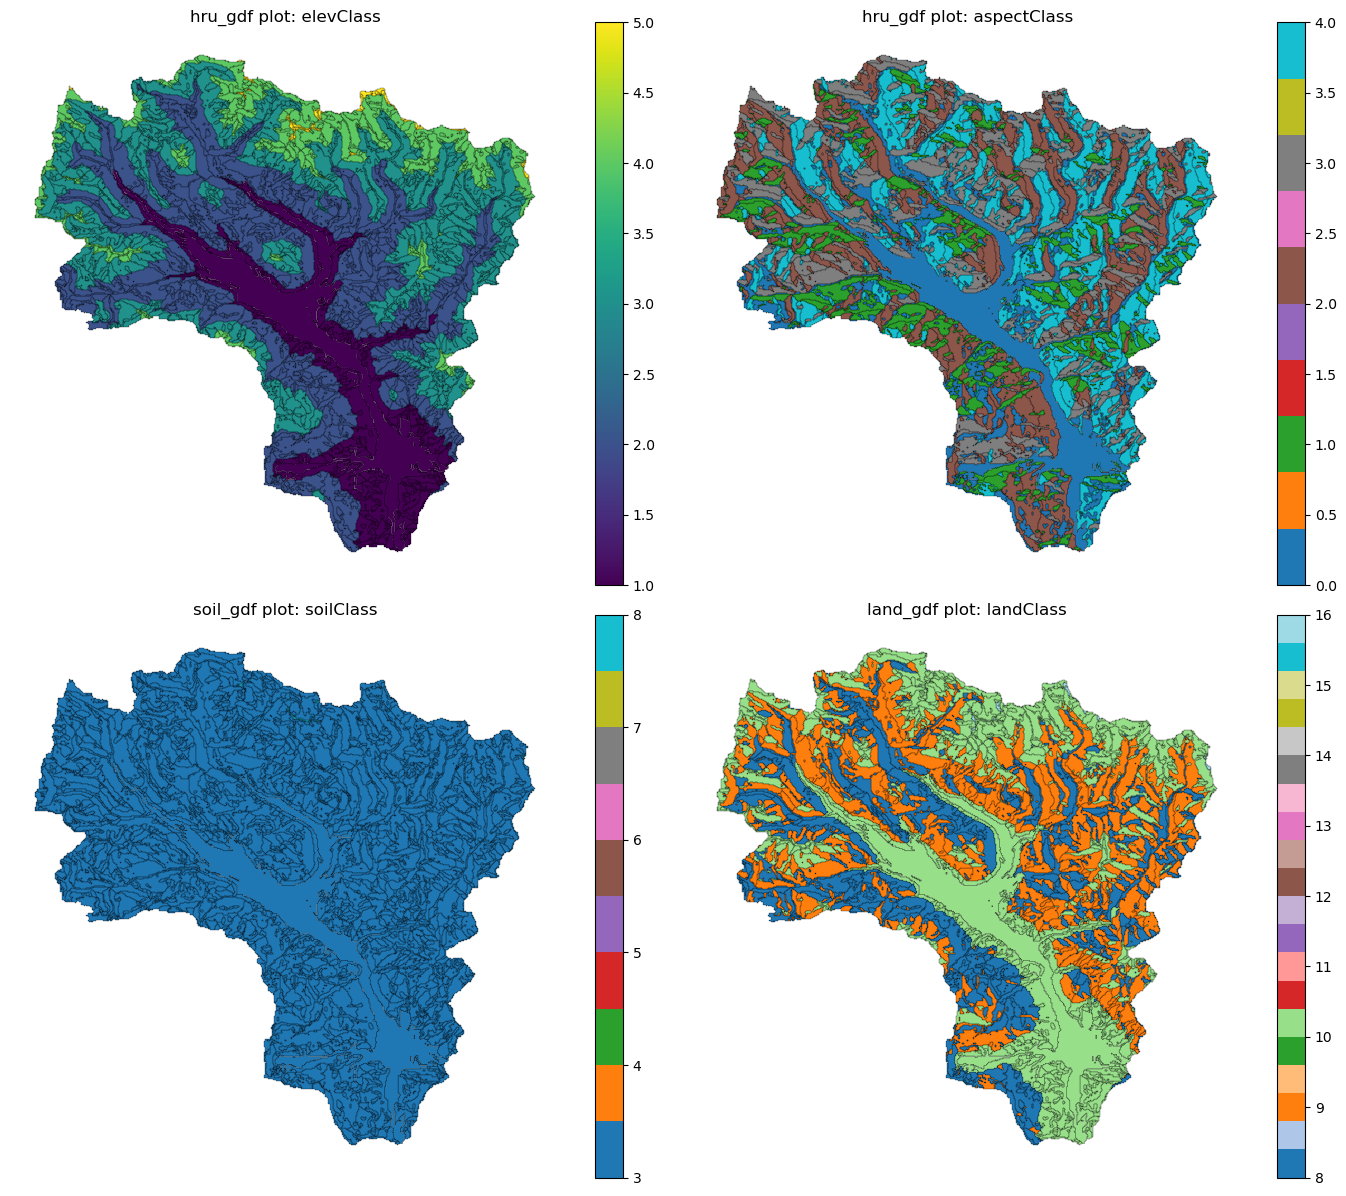

In [50]:
# Direct plots from raw shapefiles (no merge, no explode, no overlay).

def _pick_first(cols, candidates):
    for c in candidates:
        if c in cols:
            return c
    return None

elev_col = _pick_first(hru_gdf.columns, ['elevClass', 'avg_elevcl', 'elev_mean'])
aspect_col = _pick_first(hru_gdf.columns, ['aspectClass', 'aspectClas'])
soil_col = _pick_first(soil_gdf.columns, ['soilClass']) if soil_gdf is not None else None
land_col = _pick_first(land_gdf.columns, ['landClass']) if land_gdf is not None else None

print('Using HRU elevation column:', elev_col)
print('Using HRU aspect column:', aspect_col)
print('Using soil column:', soil_col)
print('Using land column:', land_col)

fig, axes = plt.subplots(2, 2, figsize=(14, 12))

if elev_col is not None:
    hru_gdf.plot(column=elev_col, cmap='viridis', legend=True, linewidth=0.2, edgecolor='black', ax=axes[0, 0])
    axes[0, 0].set_title(f'hru_gdf plot: {elev_col}')
else:
    axes[0, 0].text(0.5, 0.5, 'No elevation column', ha='center', va='center')

if aspect_col is not None:
    hru_gdf.plot(column=aspect_col, cmap='tab10', legend=True, linewidth=0.2, edgecolor='black', ax=axes[0, 1])
    axes[0, 1].set_title(f'hru_gdf plot: {aspect_col}')
else:
    axes[0, 1].text(0.5, 0.5, 'No aspect column', ha='center', va='center')

if soil_gdf is not None and soil_col is not None:
    soil_gdf.plot(column=soil_col, cmap='tab10', legend=True, linewidth=0.2, edgecolor='black', ax=axes[1, 0])
    axes[1, 0].set_title(f'soil_gdf plot: {soil_col}')
else:
    axes[1, 0].text(0.5, 0.5, 'No soil layer/column', ha='center', va='center')

if land_gdf is not None and land_col is not None:
    land_gdf.plot(column=land_col, cmap='tab20', legend=True, linewidth=0.2, edgecolor='black', ax=axes[1, 1])
    axes[1, 1].set_title(f'land_gdf plot: {land_col}')
else:
    axes[1, 1].text(0.5, 0.5, 'No land layer/column', ha='center', va='center')

for ax in axes.ravel():
    ax.set_aspect('equal')
    ax.set_axis_off()

plt.tight_layout()
plt.show()

In [51]:
# Compact table to verify ID ordering and translated classes.
show_cols = ['HRU_ID']
for c in ['elevClass', 'aspectClass', 'aspectClas', 'combined_e', 'soilClass', 'soil_name', 'landClass', 'land_name']:
    if c in hru_gdf.columns and c not in show_cols:
        show_cols.append(c)

order_df = hru_gdf[show_cols].copy()
order_df['HRU_ID'] = pd.to_numeric(order_df['HRU_ID'], errors='coerce').astype('Int64')
order_df = order_df.sort_values('HRU_ID').reset_index(drop=True)

print('Top 10 HRUs by ID:')
display(order_df.head(10))
print('Bottom 10 HRUs by ID:')
display(order_df.tail(10))

Top 10 HRUs by ID:


,HRU_ID,elevClass,aspectClass,aspectClas,combined_e,soilClass,soil_name,landClass,land_name
0,1,5,1,1,5_1,8,SANDY LOAM,10,Grasslands
1,2,5,2,2,5_2,3,LOAM,10,Grasslands
2,3,5,4,4,5_4,3,LOAM,16,Barren or Sparsely Vegetated
3,4,5,3,3,5_3,3,LOAM,10,Grasslands
4,5,5,0,0,5_0,3,LOAM,10,Grasslands
5,6,4,1,1,4_1,3,LOAM,10,Grasslands
6,7,4,2,2,4_2,3,LOAM,10,Grasslands
7,8,4,4,4,4_4,3,LOAM,10,Grasslands
8,9,4,3,3,4_3,3,LOAM,10,Grasslands
9,10,4,0,0,4_0,3,LOAM,10,Grasslands


Bottom 10 HRUs by ID:


,HRU_ID,elevClass,aspectClass,aspectClas,combined_e,soilClass,soil_name,landClass,land_name
15,16,2,1,1,2_1,3,LOAM,8,Woody Savannas
16,17,2,2,2,2_2,3,LOAM,8,Woody Savannas
17,18,2,4,4,2_4,3,LOAM,9,Savannas
18,19,2,3,3,2_3,3,LOAM,9,Savannas
19,20,2,0,0,2_0,3,LOAM,8,Woody Savannas
20,21,1,1,1,1_1,3,LOAM,10,Grasslands
21,22,1,2,2,1_2,3,LOAM,10,Grasslands
22,23,1,4,4,1_4,3,LOAM,10,Grasslands
23,24,1,3,3,1_3,3,LOAM,10,Grasslands
24,25,1,0,0,1_0,3,LOAM,10,Grasslands


In [55]:
hru_et = pd.read_csv("/scratch/dlhogan/ess-project-data/domain_East_River_distributed_elevAspect/observations/et/openet_et_per_hru_distributed_elevAspect_monthly.csv", index_col=0, parse_dates=['date'])
hru_et_2021 = hru_et[hru_et.index.month == 6].copy()
hru_et_2021 = hru_et_2021.rename(columns=lambda c: c.split('_')[1]).transpose()
hru_et_2021.index.name = 'HRU_ID'
hru_et_2021.index = hru_et_2021.index.astype('Int64')
hru_et_2021 = hru_et_2021.sort_index().sum(axis=1)

# map onto hru_gdf for plotting
hru_gdf_copy = hru_gdf.merge(hru_et_2021.rename('et_june'), left_on=hru_id_col, right_index=True, how='left')


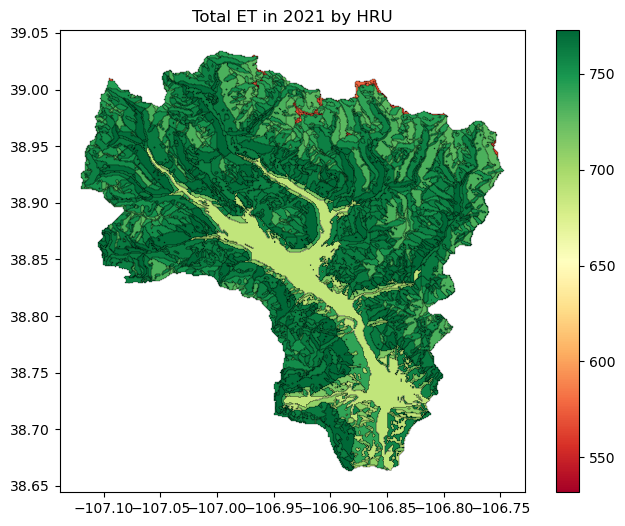

In [56]:
fig, ax = plt.subplots(1, 1, figsize=(8, 6))
hru_gdf_copy.plot(column='et_june', cmap='RdYlGn', legend=True, linewidth=0.2, edgecolor='black', ax=ax)
ax.set_title('Total ET in 2021 by HRU')
ax.set_aspect('equal')